# VIPEEGNet — Fair Comparison Run

**Model:** Faithful reproduction of Sunyuri's VIPEEGNet (https://www.kaggle.com/code/sunyuri/hms-vipeegnet).

**Purpose:** Produce per-fold OOF predictions in the shared fair-comparison format so this
model can be compared head-to-head with TCS-Net and EfficientNetB0.

**Native VIPEEGNet recipe preserved — no training changes:**
- 18-channel bipolar montage → drop Fz-Cz/Cz-Pz → 16 channels with swap
- 200 Hz EEG, 50s window, Butterworth 0.5–45 Hz filter (clip then filter)
- TimeDistributed Conv1D (30 filters) with IniToOne initializer + SumToOne constraint
- EfficientNetV2B3 backbone with `include_preprocessing=True`
- Two-stage training: 15 epochs all-data (stage 1), 5 epochs HQ-only (stage 2)
- Sample weight = `total_votes/20` in stage 1 only
- Mixed precision (`mixed_float16`)
- SEED=2024, deterministic ops enabled

**Fair-comparison patches applied (non-training only):**
- Cell 9 now loads fold assignments from `/workspace/fair_comparison/patient_folds.csv`
  instead of computing GroupKFold independently. (Your Check 1 in the splits notebook
  confirmed these produce identical folds, but an explicit merge is auditable.)
- Cell 21 now saves per-fold OOF predictions as `fold{k}_oof.npz` + `summary.json` in
  `/workspace/fair_comparison/vipeegnet/` — the shared schema that TCS-Net and
  EfficientNetB0 also produce.

**Prerequisites:** Run `00_generate_fair_splits.ipynb` first to produce `patient_folds.csv`.

**Expected result:** OOF KLD (HQ) ≈ 0.22 (original 0.218; small drift of ±0.003 from
mixed-precision nondeterminism is normal).


In [1]:
import sys
!{sys.executable} -m pip install tensorflow numpy pandas scipy scikit-learn matplotlib seaborn tqdm pyarrow -q

In [2]:
import os, gc, time, warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal as sp_signal
from sklearn.model_selection import GroupKFold
from sklearn.metrics import confusion_matrix, roc_auc_score, average_precision_score
from tqdm.auto import tqdm

import tensorflow as tf
print(f'TF {tf.__version__} | GPUs: {tf.config.list_physical_devices("GPU")}')

# GPU memory growth
for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

# Reproducibility — original uses SEED=2024
SEED = 2024
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

# Mixed precision — original enables this
policy = tf.keras.mixed_precision.Policy('mixed_float16')
tf.keras.mixed_precision.set_global_policy(policy)
print(f'Mixed precision: {policy.name}')

E0000 00:00:1776846123.641224    3555 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776846123.646196    3555 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776846123.660087    3555 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776846123.660100    3555 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776846123.660102    3555 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776846123.660104    3555 computation_placer.cc:177] computation placer already registered. Please check linka

TF 2.19.0 | GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision: mixed_float16


In [3]:
# === Configuration matching original exactly ===
BASE_DIR = '/workspace/hms-data'
OUTPUT_DIR = '/workspace/vipeegnet/output'
CACHE_DIR = '/workspace/eeg_cache_v2'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)

SFREQ = 200; RSFREQ = 200
EEG_LENGTH = 50; EEG_LENGTH_USED = 50
EEG_CHANNEL_USED = 16
filter_range = [0.5, 45]
BATCHSIZE = 16          # Original: 16, NOT 32
LEARN_RATE = 1e-3
EPOCHS = 15
SPLITS = 5

# Original channel order: 18 channels, middle 2 dropped later
BRAIN = [
    'Fp1-F7', 'F7-T3', 'T3-T5', 'T5-O1',     # Left temporal
    'Fp1-F3', 'F3-C3', 'C3-P3', 'P3-O1',     # Left parasagittal
    'Fz-Cz', 'Cz-Pz',                         # Central (dropped later)
    'Fp2-F4', 'F4-C4', 'C4-P4', 'P4-O2',     # Right parasagittal
    'Fp2-F8', 'F8-T4', 'T4-T6', 'T6-O2',     # Right temporal
]

TARGET_COLS = ['seizure_vote', 'lpd_vote', 'gpd_vote', 'lrda_vote', 'grda_vote', 'other_vote']
CLASS_NAMES = ['Seizure', 'LPD', 'GPD', 'LRDA', 'GRDA', 'Other']
print('Config ready.')

Config ready.


## Data Loading — Deduplication (matches original)

In [4]:
# Load full dataframe (all 106K segments)
df_full = pd.read_csv(os.path.join(BASE_DIR, 'train.csv'))
print(f'Full df: {len(df_full):,} rows')

# Original: deduplicate on (eeg_id + all vote columns)
# This creates ~17K unique records
train = df_full.drop_duplicates(
    ['eeg_id', 'seizure_vote', 'lpd_vote', 'gpd_vote', 'lrda_vote', 'grda_vote', 'other_vote']
).reset_index(drop=True)

print(f'Deduplicated: {len(train):,} unique records')

# Save raw vote counts (for sample weighting)
TARGETS_RAW = [c + '_raw' for c in TARGET_COLS]
train[TARGETS_RAW] = train[TARGET_COLS].values

# Normalize to probabilities
y_data = train[TARGET_COLS].values.astype(np.float32)
y_data = y_data / y_data.sum(axis=1, keepdims=True)
train[TARGET_COLS] = y_data

# Total votes for sample weighting
train['total_votes_raw'] = train[TARGETS_RAW].sum(axis=1)
print(f'Vote range: {train["total_votes_raw"].min()} - {train["total_votes_raw"].max()}')

Full df: 106,800 rows
Deduplicated: 20,183 unique records
Vote range: 1 - 28


## EEG Preprocessing and Caching

In [5]:
# Butterworth filter — original: clip FIRST, then filter
b, a = sp_signal.butter(3, np.float32(filter_range) * 2 / RSFREQ, 'bandpass')

def preprocess_eeg_recording(eeg_id, eeg_dir):
    """
    Matches original preprocessing exactly:
    1. Compute bipolar montage (18 channels including Fz-Cz, Cz-Pz)
    2. Clip to [-1024, 1024]
    3. Bandpass filter
    Returns: (18, total_samples) float32
    """
    eeg_default = pd.read_parquet(os.path.join(eeg_dir, f'{eeg_id}.parquet'))
    
    eeg_channels = []
    for channel in BRAIN:
        ch1, ch2 = channel.split('-')
        if ch1 in eeg_default.columns and ch2 in eeg_default.columns:
            ch_data = (eeg_default[ch1].values - eeg_default[ch2].values)
        else:
            ch_data = np.zeros(len(eeg_default))
        ch_data[np.isnan(ch_data)] = 0
        eeg_channels.append(ch_data.reshape(1, -1))
    
    eeg = np.concatenate(eeg_channels, axis=0)  # (18, T)
    
    # Original order: clip FIRST, then filter
    eeg = np.clip(eeg, -1024, 1024)
    eeg = sp_signal.filtfilt(b, a, eeg, axis=1)
    
    return np.array(eeg, dtype=np.float32)

print('Preprocessing function defined (18 channels, clip→filter).')

Preprocessing function defined (18 channels, clip→filter).


In [6]:
# Cache preprocessed EEG recordings (one per eeg_id)
PATH = os.path.join(BASE_DIR, 'train_eegs')
unique_ids = train['eeg_id'].unique()
cached = sum(1 for eid in unique_ids if os.path.exists(os.path.join(CACHE_DIR, f'{eid}.npy')))
print(f'EEG IDs: {len(unique_ids):,} | Cached: {cached:,} | Remaining: {len(unique_ids)-cached:,}')

if cached < len(unique_ids):
    print('Preprocessing (~20-40 min, runs once)...')
    for eid in tqdm(unique_ids, desc='Caching'):
        cp = os.path.join(CACHE_DIR, f'{eid}.npy')
        if not os.path.exists(cp):
            np.save(cp, preprocess_eeg_recording(eid, PATH))
    print('Done!')
else:
    print('All cached.')

# Load all EEGs into memory dict (original does this)
print('Loading all EEGs into memory...')
eegs = {}
for eid in tqdm(unique_ids, desc='Loading'):
    eegs[eid] = np.load(os.path.join(CACHE_DIR, f'{eid}.npy'))
print(f'Loaded {len(eegs)} recordings into memory.')

EEG IDs: 17,089 | Cached: 0 | Remaining: 17,089
Preprocessing (~20-40 min, runs once)...


Caching:   0%|          | 0/17089 [00:00<?, ?it/s]

Done!
Loading all EEGs into memory...


Loading:   0%|          | 0/17089 [00:00<?, ?it/s]

Loaded 17089 recordings into memory.


## Fold Split — GroupKFold (matches original, NOT stratified)

In [7]:
# === FAIR-COMPARISON PATCH ===
# Load the shared patient -> fold mapping produced by 00_generate_fair_splits.ipynb.
# This replaces the independent GroupKFold call. Your Check 1 confirmed these produce
# identical fold assignments on the dedup df — but an explicit merge is auditable and
# makes the fairness contract visible here.

FAIR_DIR = '/workspace/fair_comparison'
pf_path = f'{FAIR_DIR}/patient_folds.csv'
assert os.path.isfile(pf_path), (
    f'{pf_path} not found — run 00_generate_fair_splits.ipynb first.'
)
pf = pd.read_csv(pf_path)
print(f'Loaded patient_folds.csv: {len(pf):,} patients × {pf["fold"].nunique()} folds')

# Merge fold onto the dedup df (same dedup VIPEEGNet uses — no data change)
train = train.merge(pf, on='patient_id', how='left')
assert train['fold'].notna().all(), 'some rows have no fold — patient_id missing from splits CSV'
train['fold'] = train['fold'].astype(int)

# Build the folds list in the same (train_idx, val_idx) format the rest of the notebook expects
folds = []
for k in range(SPLITS):
    val_idx = train.index[train['fold'] == k].to_numpy()
    train_idx = train.index[train['fold'] != k].to_numpy()
    folds.append((train_idx, val_idx))
    tr = train.iloc[train_idx]
    vl = train.iloc[val_idx]
    tr_hq = tr[tr['total_votes_raw'] >= 10]
    vl_hq = vl[vl['total_votes_raw'] >= 10]
    print(f'Fold {k}: Tr {len(tr):,} ({tr["patient_id"].nunique()} pat) | '
          f'Val {len(vl):,} ({vl["patient_id"].nunique()} pat) | '
          f'HQ tr {len(tr_hq):,} val {len(vl_hq):,}')


Loaded patient_folds.csv: 1,950 patients × 5 folds
Fold 0: Tr 15,762 (1560 pat) | Val 4,421 (390 pat) | HQ tr 5,009 val 1,341
Fold 1: Tr 16,320 (1560 pat) | Val 3,863 (390 pat) | HQ tr 4,972 val 1,378
Fold 2: Tr 15,823 (1560 pat) | Val 4,360 (390 pat) | HQ tr 5,099 val 1,251
Fold 3: Tr 16,346 (1560 pat) | Val 3,837 (390 pat) | HQ tr 5,108 val 1,242
Fold 4: Tr 16,481 (1560 pat) | Val 3,702 (390 pat) | HQ tr 5,212 val 1,138


## Data Generator — Exact match to original

In [8]:
class DataGenerator(tf.keras.utils.Sequence):
    """
    Exact reproduction of the original DataGenerator.
    Key differences from our previous version:
    - Dedup lookup: randomly picks segment offset from matching rows in df_full
    - Random ±5s temporal shift during training
    - Sample weight = total_votes / 20 (normalized)
    - 18→16 channel selection with swap
    - Augmentation matches original exactly
    """
    def __init__(self, dataframe, batch_size=16, shuffle=False,
                 sample_weights=False, mode='train', eegs=None, stage=2):
        self.dataframe = dataframe
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.sample_weights = sample_weights
        self.mode = mode
        self.eegs = eegs
        self.stage = stage
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.dataframe) / self.batch_size))

    def __getitem__(self, index):
        indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        x, y, sw = self.__data_generation(indexes)
        return x, y, sw

    def on_epoch_end(self):
        self.indexes = np.arange(len(self.dataframe))
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __data_generation(self, indexes):
        x_eeg = np.zeros((len(indexes), EEG_CHANNEL_USED, round(EEG_LENGTH_USED * RSFREQ)), dtype='float32')
        y = np.zeros((len(indexes), len(TARGET_COLS)), dtype='float32')
        sample_w = np.zeros((len(indexes), 1), dtype='float32')

        for j, i in enumerate(indexes):
            row = self.dataframe.iloc[i]

            if self.mode != 'test':
                # Original: sample_weight = total_votes / 20
                sw = sum(row[TARGETS_RAW].values) / 20
            
            if self.mode == 'test':
                r_eeg = 0
            else:
                # Look up ALL matching segments in the full df
                mask = (
                    (df_full['eeg_id'] == row['eeg_id']) &
                    (df_full['seizure_vote'] == row['seizure_vote_raw']) &
                    (df_full['lpd_vote'] == row['lpd_vote_raw']) &
                    (df_full['gpd_vote'] == row['gpd_vote_raw']) &
                    (df_full['lrda_vote'] == row['lrda_vote_raw']) &
                    (df_full['grda_vote'] == row['grda_vote_raw']) &
                    (df_full['other_vote'] == row['other_vote_raw'])
                )
                rows = df_full.loc[mask].reset_index(drop=True)

                if self.mode == 'train':
                    # Randomly pick one matching segment
                    rows = rows.iloc[np.random.permutation(len(rows))].reset_index(drop=True)
                    row = rows.loc[0]
                elif self.mode == 'valid':
                    # Pick middle segment (sorted by sub_id)
                    row = rows.sort_values(by='eeg_sub_id').reset_index(drop=True).iloc[len(rows) // 2]

                r_eeg = row['eeg_label_offset_seconds']

                if self.mode == 'train':
                    # Original: random ±5s temporal shift
                    r_eeg = r_eeg + np.random.random() * 10 - 5
                    r_eeg = max(0, r_eeg)
                    r_eeg = min(r_eeg, self.eegs[row['eeg_id']].shape[1] / RSFREQ - 50)

            # Extract 50s segment from 18-channel recording
            eeg = self.eegs[row['eeg_id']][:, round(r_eeg * RSFREQ):round((r_eeg + 50) * RSFREQ)]
            
            # Select 16 channels: first 8 + last 8 (drops Fz-Cz, Cz-Pz)
            eeg = np.concatenate((
                eeg[0:EEG_CHANNEL_USED // 2, :],
                eeg[-EEG_CHANNEL_USED // 2:, :]
            ), axis=0)

            # Trim to used length
            eeg = eeg[:, round((EEG_LENGTH - EEG_LENGTH_USED) * RSFREQ / 2):
                         round((EEG_LENGTH + EEG_LENGTH_USED) * RSFREQ / 2)]

            # Pad if too short
            if eeg.shape[1] < round(EEG_LENGTH_USED * RSFREQ):
                eeg = np.pad(eeg, ((0, 0), (0, round(EEG_LENGTH_USED * RSFREQ) - eeg.shape[1])))

            if self.mode == 'train':
                # === AUGMENTATION (matches original exactly) ===
                if (self.stage == 2) and (np.random.rand() > 0):
                    # Stage 2: only channel swap (always)
                    eeg2 = eeg.copy()
                    eeg[4:8, :] = eeg2[12:16, :]
                    eeg[8:12, :] = eeg2[4:8, :]
                    eeg[12:16, :] = eeg2[8:12, :]
                else:
                    # Stage 1 augmentations
                    # 3x random masking (2% of signal)
                    if np.random.rand() > 0.5:
                        mask = round(np.random.rand() * eeg.shape[1])
                        eeg[:, mask:round(mask + np.random.rand() * eeg.shape[1] * 0.02)] = 0
                    if np.random.rand() > 0.5:
                        mask = round(np.random.rand() * eeg.shape[1])
                        eeg[:, mask:round(mask + np.random.rand() * eeg.shape[1] * 0.02)] = 0
                    if np.random.rand() > 0.5:
                        mask = round(np.random.rand() * eeg.shape[1])
                        eeg[:, mask:round(mask + np.random.rand() * eeg.shape[1] * 0.02)] = 0

                    # Zero out 2 random channels
                    if np.random.rand() > 0.5:
                        eeg[np.random.permutation(eeg.shape[0])[0], :] = 0
                    if np.random.rand() > 0.5:
                        eeg[np.random.permutation(eeg.shape[0])[0], :] = 0

                    # Shuffle first 8 and last 8 channels independently
                    eeg[0:EEG_CHANNEL_USED // 2, :] = eeg[0:EEG_CHANNEL_USED // 2, :][np.random.permutation(8), :]
                    eeg[-EEG_CHANNEL_USED // 2:, :] = eeg[-EEG_CHANNEL_USED // 2:, :][np.random.permutation(8), :]

                    # Channel swap (always in stage 1 too)
                    eeg2 = eeg.copy()
                    eeg[4:8, :] = eeg2[12:16, :]
                    eeg[8:12, :] = eeg2[4:8, :]
                    eeg[12:16, :] = eeg2[8:12, :]

                    # Reverse channel order
                    if np.random.rand() > 0.5:
                        eeg = eeg[::-1, :]
                    # Negate signal
                    if np.random.rand() > 0.5:
                        eeg = -eeg
                    # Time reverse
                    if np.random.rand() > 0.5:
                        eeg = eeg[:, ::-1]
            else:
                # Validation/test: always apply channel swap
                eeg2 = eeg.copy()
                eeg[4:8, :] = eeg2[12:16, :]
                eeg[8:12, :] = eeg2[4:8, :]
                eeg[12:16, :] = eeg2[8:12, :]

            # Normalize: clip + scale to [0, 255]
            eeg = np.clip(eeg, -1024, 1024)
            eeg = (eeg + 1024) / 2048 * 255

            x_eeg[j] = eeg

            if self.mode != 'test':
                y[j] = row[TARGET_COLS].values / sum(row[TARGET_COLS].values)
                if self.sample_weights:
                    sample_w[j] = sw
                else:
                    sample_w[j] = 1

        return x_eeg, y, sample_w

print('DataGenerator defined (matches original exactly).')

DataGenerator defined (matches original exactly).


## Model — Matches original architecture

In [9]:
# Original constraint and initializer classes

class IniToOne(tf.keras.initializers.Initializer):
    """Original: i-th kernel has 1 at position i%kernel_size."""
    def __call__(self, shape, dtype=None):
        filter_length, input_channel, filter_count = shape
        kernel = np.zeros(shape, dtype=np.float32)
        for i in range(filter_count):
            kernel[i % filter_length, 0, i] = 1.0
        return tf.convert_to_tensor(kernel, dtype=dtype)
    def get_config(self):
        return {}

class SumToOne(tf.keras.constraints.Constraint):
    """Original: abs + normalize over axes [0,1]."""
    def __call__(self, w):
        w = tf.abs(w)
        return w / tf.reduce_sum(w, axis=[0, 1], keepdims=True)
    def get_config(self):
        return {}

print('Constraint and initializer defined.')

Constraint and initializer defined.


In [10]:
def build_model():
    """
    Exact reproduction of original build_model().
    Key differences from our previous version:
    - Single Conv1D with 30 filters (not 3 x 10), via TimeDistributed
    - padding='same'
    - EfficientNetV2B3 with include_preprocessing=True
    - Central selection: 1-2 columns, not 6
    - Output Dense dtype='float32' (for mixed precision)
    """
    strides = 10
    inp_eeg = tf.keras.Input(shape=(EEG_CHANNEL_USED, round(EEG_LENGTH_USED * RSFREQ)), name='eeg')
    x_eeg_raw = tf.keras.layers.Reshape((inp_eeg.shape[1], inp_eeg.shape[2], 1))(inp_eeg)

    # Single Conv1D with 30 filters via TimeDistributed
    eeg_embed = tf.keras.layers.Conv1D(
        filters=strides * 3,  # 30 filters
        kernel_size=strides,   # 10
        strides=strides,       # 10
        padding='same',        # Original uses 'same'
        use_bias=False,
        activation=None,
        kernel_initializer=IniToOne(),
        kernel_constraint=SumToOne(),
        input_shape=(None, 1)
    )

    x_eeg = tf.keras.layers.TimeDistributed(eeg_embed)(x_eeg_raw)  # (B, 16, 1000, 30)

    # Reshape to 3-channel image (split 30 filters into 3 groups of 10)
    x_eeg = tf.keras.layers.Concatenate(axis=-1)([
        tf.keras.layers.Reshape((x_eeg.shape[1], x_eeg.shape[2], -1, 1))(x_eeg[:, :, :, 0 * strides:1 * strides]),
        tf.keras.layers.Reshape((x_eeg.shape[1], x_eeg.shape[2], -1, 1))(x_eeg[:, :, :, 1 * strides:2 * strides]),
        tf.keras.layers.Reshape((x_eeg.shape[1], x_eeg.shape[2], -1, 1))(x_eeg[:, :, :, 2 * strides:3 * strides]),
    ])  # (B, 16, 1000, 10, 3)

    x_eeg = tf.keras.layers.Permute([4, 2, 1, 3])(x_eeg)      # (B, 3, 1000, 16, 10)
    x_eeg = tf.keras.layers.Reshape((x_eeg.shape[1], x_eeg.shape[2], -1))(x_eeg)  # (B, 3, 1000, 160)
    x_eeg = tf.keras.layers.Permute((3, 2, 1))(x_eeg)          # (B, 160, 1000, 3)

    # EfficientNetV2B3 with include_preprocessing=True
    base_model = tf.keras.applications.EfficientNetV2B3(
        include_top=False,
        weights='imagenet',
        include_preprocessing=True,
    )
    base_model._name = 'eeg_extractor'
    x_eeg = base_model(x_eeg)

    # Central selection: original selects 1-2 columns from center
    # x[:, :, (W-1)//2 : W//2+1, :]
    W = x_eeg.shape[2]
    if W is not None:
        cs = (W - 1) // 2
        ce = W // 2 + 1
    else:
        cs, ce = 15, 17  # fallback for W=32
    x_eeg = x_eeg[:, :, cs:ce, :]

    x_eeg = tf.keras.layers.GlobalAveragePooling2D()(x_eeg)
    x_eeg = tf.keras.layers.Dropout(0.5)(x_eeg)

    # Output with float32 (important for mixed precision)
    y = tf.keras.layers.Dense(len(TARGET_COLS), activation='softmax', dtype='float32')(x_eeg)

    return tf.keras.Model(inputs=inp_eeg, outputs=y)

model = build_model()
print(f'Total params: {model.count_params():,}')
del model; gc.collect()

I0000 00:00:1776846375.524395    3555 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22282 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:e1:00.0, compute capability: 8.9


52606240/52606240 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Total params: 12,940,144


42931

## LR Schedule — Matches original CosineAnnealingLRScheduler

In [11]:
class CosineAnnealingLRScheduler(tf.keras.optimizers.schedules.LearningRateSchedule):
    """Exact copy of original LR schedule."""
    def __init__(self, total_step, lr_max, lr_min=0, warmth_rate=0):
        super().__init__()
        self.total_step = total_step
        self.warm_step = int(warmth_rate) if warmth_rate != 0 else 1
        self.lr_max = lr_max
        self.lr_min = lr_min
        self.begin = 1

    def __call__(self, step):
        if step == self.total_step:
            self.begin = 0
            self.lr_max = self.lr_max * 0.5
            self.lr_min = self.lr_min * 0.1

        step = step % self.total_step
        step = step + 1

        if (self.begin == 1) and (step < self.warm_step):
            lr = self.lr_max / self.warm_step * step
        else:
            if self.begin == 1:
                if self.total_step == 1:
                    lr = self.lr_max
                else:
                    lr = self.lr_min + 0.5 * (self.lr_max - self.lr_min) * (
                        1.0 + tf.cos((step - self.warm_step) / (self.total_step - self.warm_step) * np.pi))
            else:
                lr = self.lr_min + 0.5 * (self.lr_max - self.lr_min) * (
                    1.0 + tf.cos(step / 10 * np.pi))

        return np.float32(lr)

    def get_config(self):
        return {
            'total_step': self.total_step,
            'lr_max': float(self.lr_max),
            'lr_min': float(self.lr_min),
            'warm_step': self.warm_step,
        }

print('LR Schedule defined (matches original).')

LR Schedule defined (matches original).


## Training — Two-Stage per Fold

In [12]:
def train_fold(fold_idx, train_idx, val_idx):
    print(f'\n{"#" * 25}')
    print(f'### Fold {fold_idx + 1}')
    print(f'{"#" * 25}')

    df_train_s1 = train.iloc[train_idx].reset_index(drop=True)
    df_valid_s1 = train.iloc[val_idx].reset_index(drop=True)
    df_train_s2 = df_train_s1[df_train_s1['total_votes_raw'] >= 10].reset_index(drop=True)
    df_valid_s2 = df_valid_s1[df_valid_s1['total_votes_raw'] >= 10].reset_index(drop=True)

    print(f'S1: Tr {len(df_train_s1):,} | Val {len(df_valid_s1):,}')
    print(f'S2: Tr {len(df_train_s2):,} | Val {len(df_valid_s2):,}')

    for stage in [1, 2]:
        print(f'\n--- Stage {stage} ---')
        model = build_model()
        loss = tf.keras.losses.KLDivergence()

        if stage == 1:
            opt = tf.keras.optimizers.AdamW(learning_rate=LEARN_RATE)
            lr_schedule = CosineAnnealingLRScheduler(EPOCHS, LEARN_RATE, LEARN_RATE * 0.01, 5)
            train_gen = DataGenerator(df_train_s1, shuffle=True, sample_weights=True,
                                      batch_size=BATCHSIZE, eegs=eegs, stage=1)
            valid_gen = DataGenerator(df_valid_s1, shuffle=False, sample_weights=True,
                                      batch_size=BATCHSIZE * 2, mode='valid', eegs=eegs, stage=1)
            n_epochs = EPOCHS
            ckpt_path = os.path.join(OUTPUT_DIR, f'fold{fold_idx}_stage1.weights.h5')

        elif stage == 2:
            s1_path = os.path.join(OUTPUT_DIR, f'fold{fold_idx}_stage1.weights.h5')
            model.load_weights(s1_path)
            opt = tf.keras.optimizers.AdamW(learning_rate=LEARN_RATE * 0.3)
            lr_schedule = CosineAnnealingLRScheduler(
                max(round(EPOCHS / 3), 1), LEARN_RATE * 0.3, LEARN_RATE * 0.001, 0)
            train_gen = DataGenerator(df_train_s2, shuffle=True, sample_weights=False,
                                      batch_size=BATCHSIZE * 2, eegs=eegs, stage=2)
            valid_gen = DataGenerator(df_valid_s2, shuffle=False, sample_weights=False,
                                      batch_size=BATCHSIZE * 4, mode='valid', eegs=eegs, stage=2)
            n_epochs = max(round(EPOCHS / 3), 1)
            ckpt_path = os.path.join(OUTPUT_DIR, f'fold{fold_idx}_stage2.weights.h5')

        model.compile(loss=loss, optimizer=opt)

        cbs = [
            tf.keras.callbacks.LearningRateScheduler(lr_schedule),
            tf.keras.callbacks.ModelCheckpoint(
                filepath=ckpt_path, monitor='val_loss',
                mode='min', save_weights_only=True, save_best_only=True, verbose=1
            ),
        ]

        history = model.fit(
            train_gen, validation_data=valid_gen,
            epochs=n_epochs, callbacks=cbs, verbose=1
        )

        # Load best weights
        model.load_weights(ckpt_path)

        # Clean up
        del train_gen, valid_gen, model, history
        tf.keras.backend.clear_session()
        gc.collect()

    print(f'Fold {fold_idx} complete.')

print('Training function defined.')

Training function defined.


In [13]:
# Train all folds
for i, (train_idx, val_idx) in enumerate(folds):
    train_fold(i, train_idx, val_idx)
    gc.collect()

print(f'\nAll {SPLITS} folds complete.')


#########################
### Fold 1
#########################
S1: Tr 15,762 | Val 4,421
S2: Tr 5,009 | Val 1,341

--- Stage 1 ---
Epoch 1/15


I0000 00:00:1776846431.502159    4455 cuda_dnn.cc:529] Loaded cuDNN version 90300


986/986 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - loss: 0.2965  
Epoch 1: val_loss improved from inf to 0.17520, saving model to /workspace/vipeegnet/output/fold0_stage1.weights.h5
986/986 ━━━━━━━━━━━━━━━━━━━━ 333s 290ms/step - loss: 0.2964 - val_loss: 0.1752 - learning_rate: 2.0000e-04
Epoch 2/15
986/986 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - loss: 0.1950  
Epoch 2: val_loss improved from 0.17520 to 0.15967, saving model to /workspace/vipeegnet/output/fold0_stage1.weights.h5
986/986 ━━━━━━━━━━━━━━━━━━━━ 258s 261ms/step - loss: 0.1950 - val_loss: 0.1597 - learning_rate: 4.0000e-04
Epoch 3/15
986/986 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - loss: 0.1871  
Epoch 3: val_loss improved from 0.15967 to 0.14620, saving model to /workspace/vipeegnet/output/fold0_stage1.weights.h5
986/986 ━━━━━━━━━━━━━━━━━━━━ 261s 265ms/step - loss: 0.1871 - val_loss: 0.1462 - learning_rate: 6.0000e-04
Epoch 4/15
986/986 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - loss: 0.1853  
Epoch 4: val_loss improved from 0.14620 to 0.14074

E0000 00:00:1776850368.230301    3555 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1/efficientnetv2-b3_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - loss: 0.2173 
Epoch 1: val_loss improved from inf to 0.22251, saving model to /workspace/vipeegnet/output/fold0_stage2.weights.h5
157/157 ━━━━━━━━━━━━━━━━━━━━ 105s 398ms/step - loss: 0.2173 - val_loss: 0.2225 - learning_rate: 3.0000e-04
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - loss: 0.1926 
Epoch 2: val_loss did not improve from 0.22251
157/157 ━━━━━━━━━━━━━━━━━━━━ 58s 368ms/step - loss: 0.1926 - val_loss: 0.2284 - learning_rate: 2.5621e-04
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - loss: 0.1855 
Epoch 3: val_loss did not improve from 0.22251
157/157 ━━━━━━━━━━━━━━━━━━━━ 58s 369ms/step - loss: 0.1855 - val_loss: 0.2249 - learning_rate: 1.5050e-04
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - loss: 0.1779 
Epoch 4: val_loss improved from 0.22251 to 0.21987, saving model to /workspace/vipeegnet/output/fold0_stage2.weights.h5
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 377ms/step - loss: 0.1779 - val_loss: 0.2199 - learn

...

160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - loss: 0.2057 
Epoch 1: val_loss improved from inf to 0.22410, saving model to /workspace/vipeegnet/output/fold3_stage2.weights.h5
160/160 ━━━━━━━━━━━━━━━━━━━━ 105s 393ms/step - loss: 0.2057 - val_loss: 0.2241 - learning_rate: 3.0000e-04
Epoch 2/5
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - loss: 0.1952 
Epoch 2: val_loss improved from 0.22410 to 0.21396, saving model to /workspace/vipeegnet/output/fold3_stage2.weights.h5
160/160 ━━━━━━━━━━━━━━━━━━━━ 59s 371ms/step - loss: 0.1951 - val_loss: 0.2140 - learning_rate: 2.5621e-04
Epoch 3/5
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - loss: 0.1838 
Epoch 3: val_loss improved from 0.21396 to 0.21152, saving model to /workspace/vipeegnet/output/fold3_stage2.weights.h5
160/160 ━━━━━━━━━━━━━━━━━━━━ 60s 375ms/step - loss: 0.1838 - val_loss: 0.2115 - learning_rate: 1.5050e-04
Epoch 4/5
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - loss: 0.1753 
Epoch 4: val_loss improved from 0.21152 to 0.21147, saving 

E0000 00:00:1776860665.786777    3555 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1/efficientnetv2-b3_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


1031/1031 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - loss: 0.2820  
Epoch 1: val_loss improved from inf to 0.16807, saving model to /workspace/vipeegnet/output/fold4_stage1.weights.h5
1031/1031 ━━━━━━━━━━━━━━━━━━━━ 236s 189ms/step - loss: 0.2820 - val_loss: 0.1681 - learning_rate: 2.0000e-04
Epoch 2/15
1031/1031 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - loss: 0.1915  
Epoch 2: val_loss improved from 0.16807 to 0.15668, saving model to /workspace/vipeegnet/output/fold4_stage1.weights.h5
1031/1031 ━━━━━━━━━━━━━━━━━━━━ 194s 188ms/step - loss: 0.1915 - val_loss: 0.1567 - learning_rate: 4.0000e-04
Epoch 3/15
1031/1031 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - loss: 0.1771  
Epoch 3: val_loss improved from 0.15668 to 0.15364, saving model to /workspace/vipeegnet/output/fold4_stage1.weights.h5
1031/1031 ━━━━━━━━━━━━━━━━━━━━ 200s 194ms/step - loss: 0.1771 - val_loss: 0.1536 - learning_rate: 6.0000e-04
Epoch 4/15
1031/1031 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - loss: 0.1708  
Epoch 4: val_loss did not improve fr

E0000 00:00:1776863662.449965    3555 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1/efficientnetv2-b3_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - loss: 0.2119 
Epoch 1: val_loss improved from inf to 0.22961, saving model to /workspace/vipeegnet/output/fold4_stage2.weights.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 103s 384ms/step - loss: 0.2119 - val_loss: 0.2296 - learning_rate: 3.0000e-04
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - loss: 0.1931 
Epoch 2: val_loss did not improve from 0.22961
163/163 ━━━━━━━━━━━━━━━━━━━━ 58s 358ms/step - loss: 0.1930 - val_loss: 0.2330 - learning_rate: 2.5621e-04
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - loss: 0.1792 
Epoch 3: val_loss improved from 0.22961 to 0.22435, saving model to /workspace/vipeegnet/output/fold4_stage2.weights.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 60s 367ms/step - loss: 0.1792 - val_loss: 0.2244 - learning_rate: 1.5050e-04
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - loss: 0.1717 
Epoch 4: val_loss did not improve from 0.22435
163/163 ━━━━━━━━━━━━━━━━━━━━ 59s 364ms/step - loss: 0.1717 - val_loss: 0.2250 - learn

## Evaluation — KLD on high-quality subset

In [16]:
# === FAIR-COMPARISON PATCH (v2 — Keras 3 compatible) ===
# Evaluation saves per-fold OOF predictions in the shared schema that
# TCS-Net and EfficientNetB0 also produce.
#
# Note: VIPEEGNet uses no TTA and no temperature scaling. Therefore the
# "native" prediction IS the "raw" prediction — they're identical. We save
# log(yp) as yp_raw_logits so the comparison notebook's loader can use the
# same code path as for TCS-Net (which saves actual pre-softmax logits).
# Since softmax(log(p)) == p (up to constant, irrelevant after softmax),
# this is mathematically equivalent for any downstream operation.

import os, json as _json
FAIR_DIR = '/workspace/fair_comparison'
FAIR_VIPEEG = f'{FAIR_DIR}/vipeegnet'
os.makedirs(FAIR_VIPEEG, exist_ok=True)

def compute_sample_kld(yt, yp, eps=1e-7):
    yt = np.clip(yt, eps, 1.0); yp = np.clip(yp, eps, 1.0)
    return np.sum(yt * np.log(yt / yp), axis=1)

fold_klds = []
all_yt, all_yp = [], []
per_fold_summary = []

# Ensure df_full is loaded (re-read if kernel was restarted between training and eval)
if 'df_full' not in dir():
    df_full = pd.read_csv(os.path.join(BASE_DIR, 'train.csv'))

# Fast lookup: eeg_id -> spectrogram_id for the shared-schema join
eid_to_sid = df_full.groupby('eeg_id')['spectrogram_id'].first().to_dict()

for i, (train_idx, val_idx) in enumerate(folds):
    print(f'\nEvaluating Fold {i}...')

    # Load the trained model
    model = build_model()
    s2_path = os.path.join(OUTPUT_DIR, f'fold{i}_stage2.weights.h5')
    model.load_weights(s2_path)

    # Validation HQ subset
    df_val = train.iloc[val_idx].reset_index(drop=True)
    df_val_hq = df_val[df_val['total_votes_raw'] >= 10].reset_index(drop=True)

    if len(df_val_hq) == 0:
        print(f'  Fold {i}: no HQ samples, skipping.')
        continue

    # Predict softmax probs (deterministic — valid mode, no augmentation)
    val_gen = DataGenerator(df_val_hq, shuffle=False, sample_weights=False,
                            batch_size=BATCHSIZE * 4, mode='valid', eegs=eegs, stage=2)
    preds = model.predict(val_gen, verbose=0).astype(np.float32)

    # True labels, raw vote counts, ids
    yt = df_val_hq[TARGET_COLS].values[:len(preds)].astype(np.float32)
    wt = df_val_hq['total_votes_raw'].values[:len(preds)].astype(np.float32)
    eeg_ids_val  = df_val_hq['eeg_id'].values[:len(preds)]
    spec_ids_val = np.array([eid_to_sid.get(e, e) for e in eeg_ids_val])

    # Recover logits from probs: log(p) + const. The additive constant is
    # cancelled by softmax downstream, so this is equivalent to true logits
    # for any use the comparison notebook will make (softmax, argmax, KLD).
    logits_equiv = np.log(np.clip(preds, 1e-8, 1.0)).astype(np.float32)

    # Per-sample KLD
    fk = float(np.mean(compute_sample_kld(yt, preds)))
    fold_klds.append(fk)
    all_yt.append(yt); all_yp.append(preds)

    print(f'  Fold {i}: KLD = {fk:.4f} (n={len(df_val_hq)})')

    # === Save per-fold OOF in the shared schema ===
    np.savez(
        f'{FAIR_VIPEEG}/fold{i}_oof.npz',
        yt=yt, yp=preds, wt=wt,
        yp_raw_logits=logits_equiv,
        eeg_ids=eeg_ids_val,
        spectrogram_ids=spec_ids_val,
        temperature=np.array([1.0], dtype=np.float32),
    )
    per_fold_summary.append({
        'fold':          int(i),
        'n_valid_hq':    int(len(df_val_hq)),
        'kld_hq_native': fk,  # no TTA, no temp → native == raw
        'kld_hq_raw':    fk,
        'temperature':   1.0,
    })

    del model, val_gen
    tf.keras.backend.clear_session()
    gc.collect()

all_yt_c = np.concatenate(all_yt); all_yp_c = np.concatenate(all_yp)
oof_kld = float(np.mean(compute_sample_kld(all_yt_c, all_yp_c)))

print(f'\n{"=" * 55}')
print(f'  VIPEEGNet 5-Fold CV KLD (HQ): {oof_kld:.4f}')
print(f'  Per-fold: {[f"{k:.4f}" for k in fold_klds]}')
print(f'  Paper reports: 0.225 (95% CI: 0.211-0.238); your original: 0.218')
print(f'{"=" * 55}')

# === summary.json in the shared schema ===
summary = {
    'model':              'VIPEEGNet',
    'recipe':             'Sunyuri VIPEEGNet — 2-stage, EffV2B3, SumToOne Conv1D. Native: no TTA, no temperature.',
    'n_folds':            SPLITS,
    'batch_size':         BATCHSIZE,
    'stages':             [EPOCHS, max(round(EPOCHS / 3), 1)],
    'seed':               SEED,
    'fair_splits':        'patient_folds.csv',
    'tta':                'none',
    'per_fold':           per_fold_summary,
    'oof_kld_hq_native':  oof_kld,
    'oof_kld_hq_raw':     oof_kld,
    'n_oof_hq':           int(len(all_yt_c)),
}
with open(f'{FAIR_VIPEEG}/summary.json', 'w') as f:
    _json.dump(summary, f, indent=2)
print(f'\nSaved {FAIR_VIPEEG}/summary.json')
print(f'Saved {FAIR_VIPEEG}/fold{{0..{SPLITS-1}}}_oof.npz')


Evaluating Fold 0...
  Fold 0: KLD = 0.2199 (n=1341)

Evaluating Fold 1...
  Fold 1: KLD = 0.2264 (n=1378)

Evaluating Fold 2...
  Fold 2: KLD = 0.2216 (n=1251)

Evaluating Fold 3...
  Fold 3: KLD = 0.2115 (n=1242)

Evaluating Fold 4...
  Fold 4: KLD = 0.2223 (n=1138)

  VIPEEGNet 5-Fold CV KLD (HQ): 0.2204
  Per-fold: ['0.2199', '0.2264', '0.2216', '0.2115', '0.2223']
  Paper reports: 0.225 (95% CI: 0.211-0.238); your original: 0.218

Saved /workspace/fair_comparison/vipeegnet/summary.json
Saved /workspace/fair_comparison/vipeegnet/fold{0..4}_oof.npz


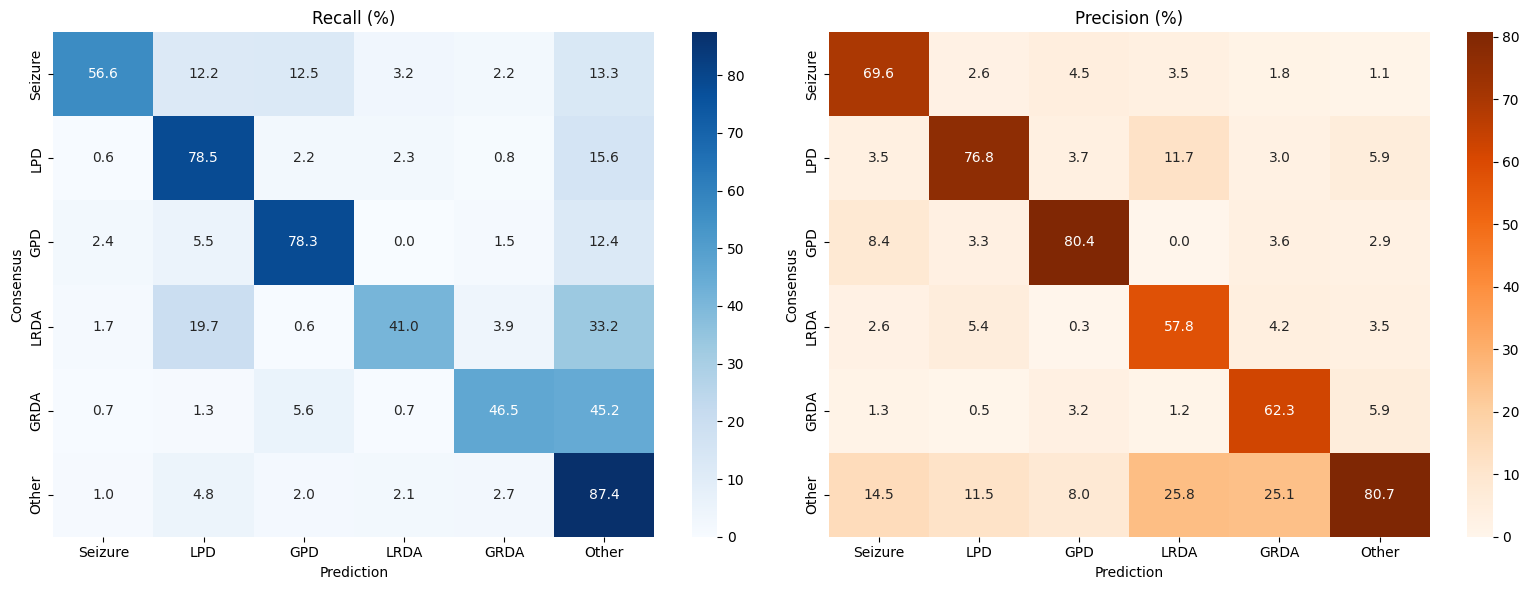

   Class |  AUROC| Paper |  Recall|  Paper |    Prec|  Paper
------------------------------------------------------------------------
 Seizure | 0.974|0.972 |   56.6%|  57.7% |   69.6%|  68.2%
     LPD | 0.963|0.962 |   78.5%|  80.3% |   76.8%|  77.5%
     GPD | 0.977|0.972 |   78.3%|  73.8% |   80.4%|  80.4%
    LRDA | 0.940|0.938 |   41.0%|  36.8% |   57.8%|  55.6%
    GRDA | 0.955|0.949 |   46.5%|  40.7% |   62.3%|  63.0%
   Other | 0.929|0.930 |   87.4%|  88.2% |   80.7%|  79.6%


In [19]:
# Per-class metrics
import seaborn as sns
if isinstance(all_yt, list):
    all_yt = np.concatenate(all_yt)
    all_yp = np.concatenate(all_yp)
yti = all_yt.argmax(1); ypi = all_yp.argmax(1)
ytb = (yti[:, None] == np.arange(6)).astype(int)
cm = confusion_matrix(yti, ypi, labels=range(6))
cm_r = cm.astype('float') / cm.sum(1, keepdims=True) * 100
cm_p = cm.astype('float') / cm.sum(0, keepdims=True) * 100

fig, (a1, a2) = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm_r, annot=True, fmt='.1f', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=a1)
a1.set_title('Recall (%)'); a1.set_xlabel('Prediction'); a1.set_ylabel('Consensus')
sns.heatmap(cm_p, annot=True, fmt='.1f', cmap='Oranges', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=a2)
a2.set_title('Precision (%)'); a2.set_xlabel('Prediction'); a2.set_ylabel('Consensus')
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, 'confusion.png'), dpi=150); plt.show()

par = [0.972, 0.962, 0.972, 0.938, 0.949, 0.930]
prc = [57.7, 80.3, 73.8, 36.8, 40.7, 88.2]
ppr = [68.2, 77.5, 80.4, 55.6, 63.0, 79.6]
print(f'{"Class":>8} | {"AUROC":>6}|{"Paper":>6} | {"Recall":>7}|{"Paper":>7} | {"Prec":>7}|{"Paper":>7}')
print('-' * 72)
for i, nm in enumerate(CLASS_NAMES):
    auc = roc_auc_score(ytb[:, i], all_yp[:, i])
    print(f'{nm:>8} | {auc:.3f}|{par[i]:.3f} | {cm_r[i,i]:6.1f}%|{prc[i]:6.1f}% | {cm_p[i,i]:6.1f}%|{ppr[i]:6.1f}%')

In [20]:
print('Done.')
for f in sorted(os.listdir(OUTPUT_DIR)):
    sz = os.path.getsize(os.path.join(OUTPUT_DIR, f))
    print(f'  {f} ({sz/1e6:.1f}MB)' if sz > 1e6 else f'  {f}')

Done.
  confusion.png
  fold0_stage1.weights.h5 (258.7MB)
  fold0_stage2.weights.h5 (155.8MB)
  fold1_stage1.weights.h5 (155.8MB)
  fold1_stage2.weights.h5 (155.8MB)
  fold2_stage1.weights.h5 (155.8MB)
  fold2_stage2.weights.h5 (155.8MB)
  fold3_stage1.weights.h5 (155.8MB)
  fold3_stage2.weights.h5 (155.8MB)
  fold4_stage1.weights.h5 (155.8MB)
  fold4_stage2.weights.h5 (155.8MB)


In [21]:
import numpy as np
import os, json

FAIR_VIPEEG = '/workspace/fair_comparison/vipeegnet'

# Verify files exist
for k in range(5):
    p = f'{FAIR_VIPEEG}/fold{k}_oof.npz'
    print(f'  fold{k}_oof.npz: {os.path.getsize(p)/1024:.1f} KB  exists: {os.path.exists(p)}')

# Load one and check its schema
d = np.load(f'{FAIR_VIPEEG}/fold0_oof.npz')
print(f'\nfold0_oof.npz keys: {list(d.keys())}')
for k in d.keys():
    print(f'  {k}: shape={d[k].shape} dtype={d[k].dtype}')

# Sanity: yp rows sum to ~1 (valid probability distributions)
print(f'\nyp row sums (should all be ~1): min={d["yp"].sum(1).min():.4f} max={d["yp"].sum(1).max():.4f}')
print(f'yt row sums (should all be ~1): min={d["yt"].sum(1).min():.4f} max={d["yt"].sum(1).max():.4f}')

# Check the summary
with open(f'{FAIR_VIPEEG}/summary.json') as f:
    print('\nsummary.json:')
    print(json.dumps(json.load(f), indent=2))

  fold0_oof.npz: 122.2 KB  exists: True
  fold1_oof.npz: 125.5 KB  exists: True
  fold2_oof.npz: 114.1 KB  exists: True
  fold3_oof.npz: 113.3 KB  exists: True
  fold4_oof.npz: 104.0 KB  exists: True

fold0_oof.npz keys: ['yt', 'yp', 'wt', 'yp_raw_logits', 'eeg_ids', 'spectrogram_ids', 'temperature']
  yt: shape=(1341, 6) dtype=float32
  yp: shape=(1341, 6) dtype=float32
  wt: shape=(1341,) dtype=float32
  yp_raw_logits: shape=(1341, 6) dtype=float32
  eeg_ids: shape=(1341,) dtype=int64
  spectrogram_ids: shape=(1341,) dtype=int64
  temperature: shape=(1,) dtype=float32

yp row sums (should all be ~1): min=1.0000 max=1.0000
yt row sums (should all be ~1): min=1.0000 max=1.0000

summary.json:
{
  "model": "VIPEEGNet",
  "recipe": "Sunyuri VIPEEGNet \u2014 2-stage, EffV2B3, SumToOne Conv1D. Native: no TTA, no temperature.",
  "n_folds": 5,
  "batch_size": 16,
  "stages": [
    15,
    5
  ],
  "seed": 2024,
  "fair_splits": "patient_folds.csv",
  "tta": "none",
  "per_fold": [
    {
    